In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.stats import norm
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams['font.size'] = 15

In [2]:
files = ! ls Final_Chunk*.pkl
bucket = []
for item in files:
    bucket.append( pd.read_pickle(item) )
df = pd.concat(bucket, ignore_index=True)
print(f"The dataframe has", len(df), "rows and", len(df.columns), "columns.")
memory = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"It occupies {memory:.2f} MB")
df.head()

The dataframe has 3490378 rows and 5 columns.
It occupies 133.15 MB


,mass,dcaXY,pt,cos_pointing,decay_length
0,1.821499,-0.000005,0.775502,0.923646,0.007234
1,1.832552,-0.000004,1.448730,0.962763,0.004363
2,1.842711,-0.000010,2.671746,0.991940,0.027235
3,2.077747,-0.000007,2.760309,0.991226,0.020889
4,2.127117,-0.000036,2.288202,0.997269,0.014921


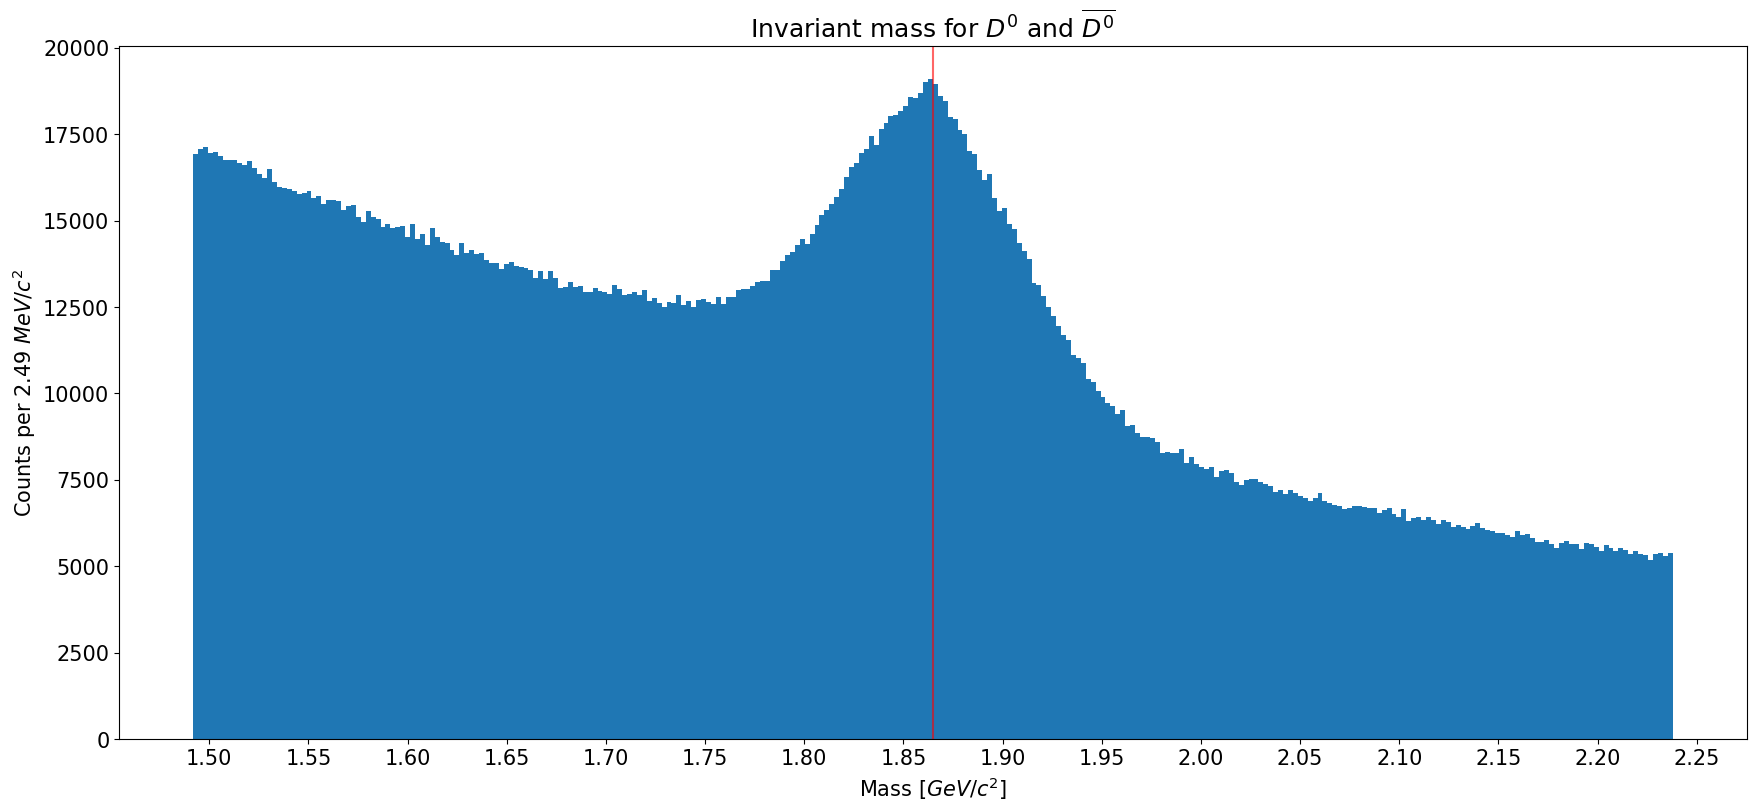

In [3]:
N_BINS = 300
m_d0 = 1.86484
MIN_MASS, MAX_MASS = 0.8*m_d0, 1.2*m_d0
STEP = (MAX_MASS-MIN_MASS)/N_BINS

fig, ax = plt.subplots(figsize=(21,9))
counts, edges, graph = plt.hist(df["mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS), align="mid")
plt.xlabel(r"Mass $[GeV/c^2]$")
plt.ylabel(f"Counts per {STEP*1000:.2f} $MeV/c^2$")
plt.xticks(np.arange(1.50,2.26, 0.05))
plt.axvline(x=m_d0, color="red", alpha=0.6)
plt.title(r"Invariant mass for $D^0$ and $\overline{D^0}$")
plt.show()

/tmp/ipykernel_22475/1210723968.py:6: RuntimeWarning: overflow encountered in exp
  return ( N * norm.pdf( x, loc = mu, scale = sig ) + pedestal + A*np.exp( ( x - off ) / tau ) )


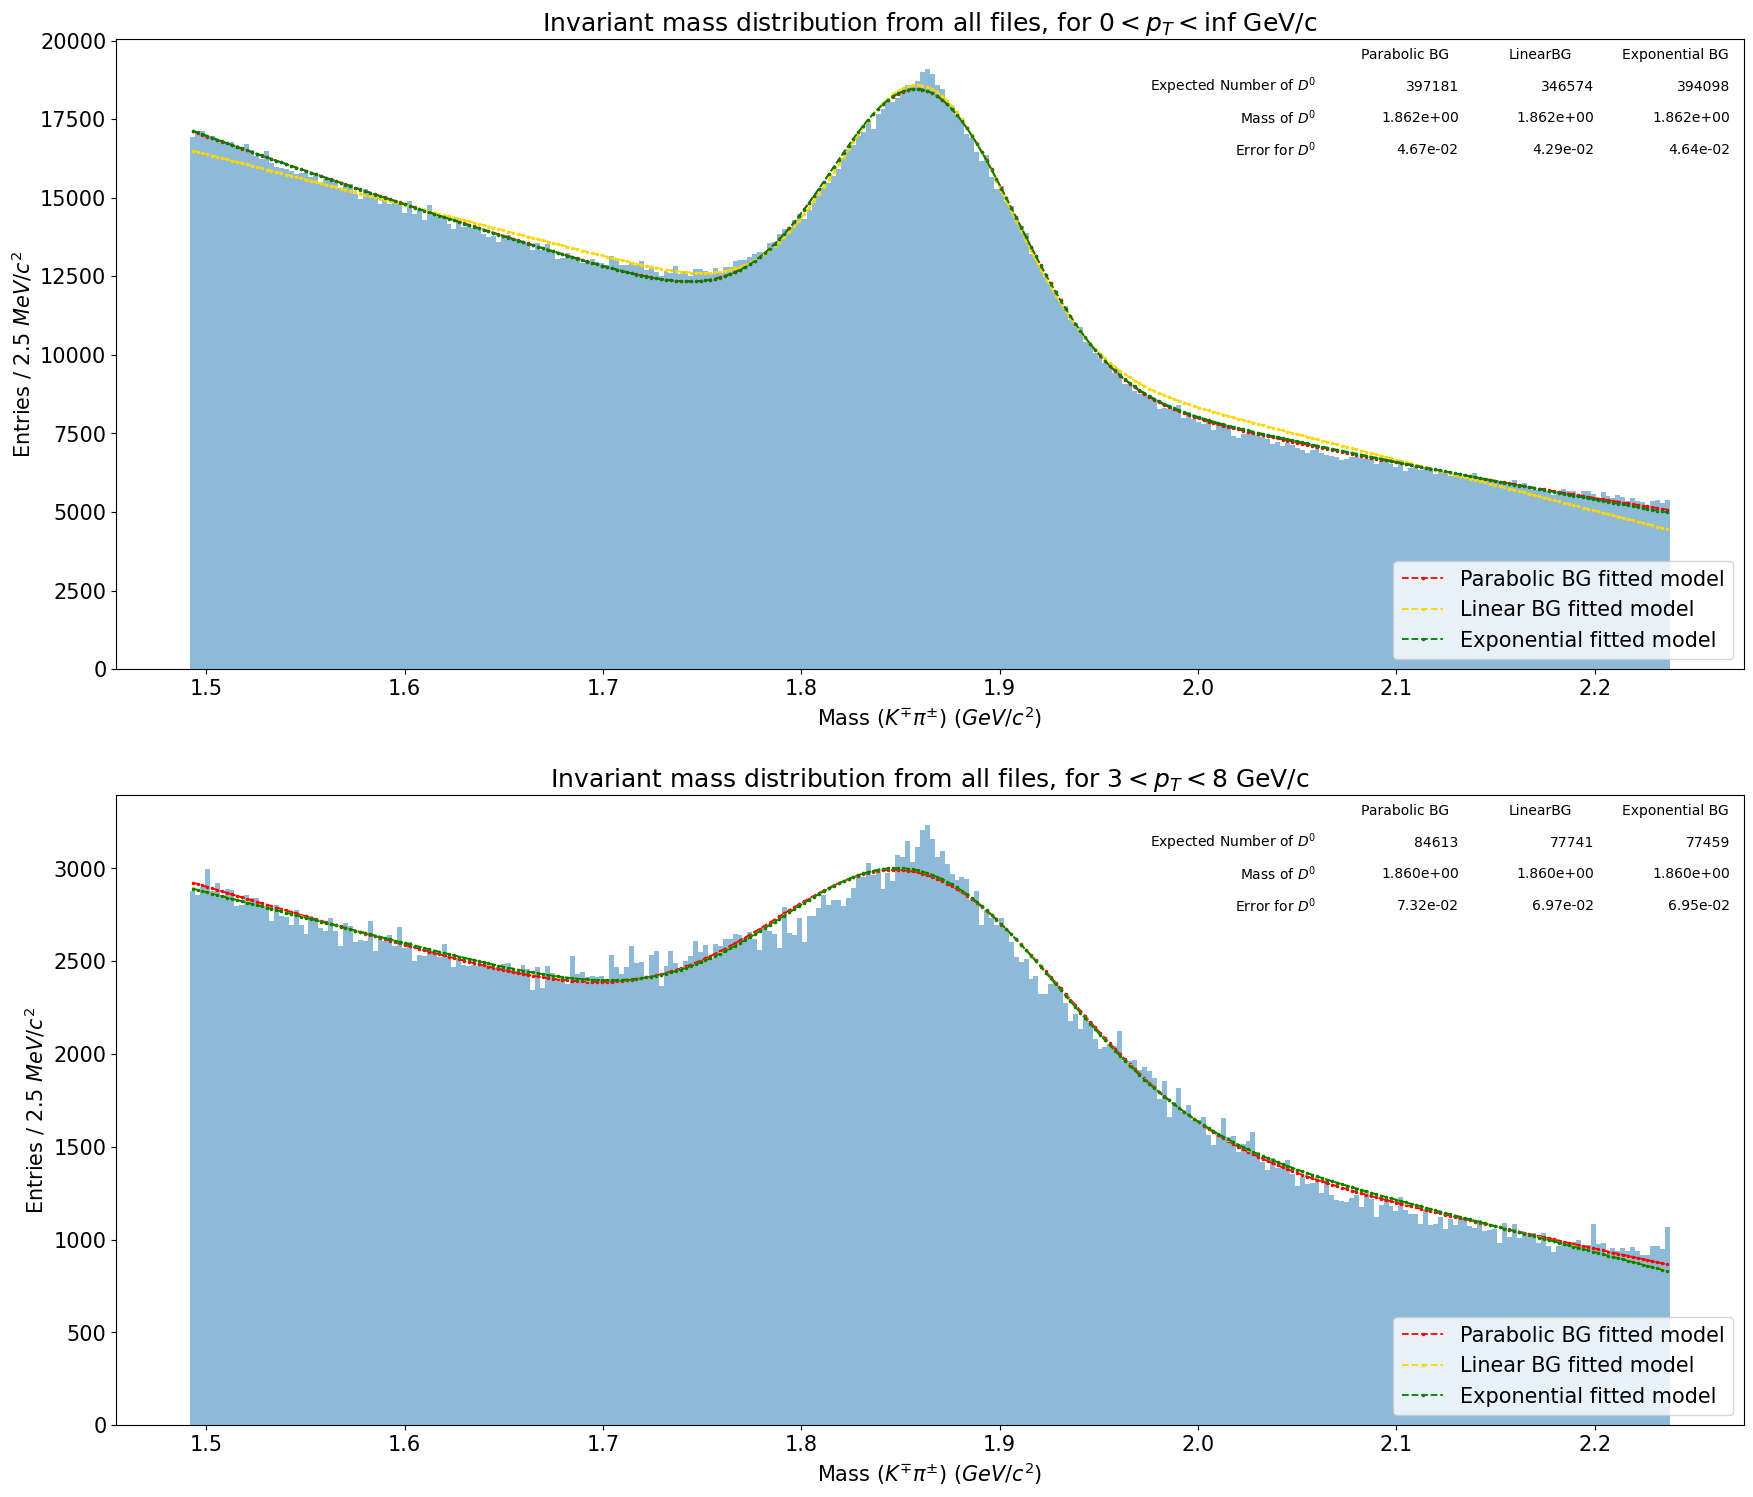

,Background,Pt_interval,Amplitude,Pedestal,Mu,Sigma,Slope,B,A,Tau,Offset,D0_counts
0,Linear,"[0, inf]",864.0717,40700.2918,1.8620,0.0429,-16207.3266,NaN,NaN,NaN,NaN,346573.5191
1,Parabolic,"[0, inf]",990.2456,69969.9337,1.8619,0.0467,NaN,-48220.7486,8587.1604,NaN,NaN,397181.0318
2,Exponential,"[0, inf]",982.5601,-5959.3372,1.8617,0.0464,NaN,NaN,NaN,-0.9959,2.9846,394098.4262
3,Linear,"[3, 8]",193.8233,7030.0533,1.8603,0.0697,-2771.2596,NaN,NaN,NaN,NaN,77741.2697
4,Parabolic,"[3, 8]",210.9567,9077.2899,1.8602,0.0732,NaN,-5024.7506,605.0502,NaN,NaN,84613.3623
5,Exponential,"[3, 8]",193.1204,150235.6618,1.8604,0.0695,NaN,NaN,NaN,53.5382,0.0312,77459.3194


In [8]:
def parabolic_model( x, pedestal, N, mu, sig, B, A ) :
    return ( N * norm.pdf( x, loc = mu, scale = sig ) + pedestal + B*x + A*x**2 )
def linear_model( x, pedestal, N, mu, sig, rho ) :
    return ( N * norm.pdf( x, loc = mu, scale = sig )  + pedestal + x * rho )
def exponential_model( x, pedestal, N, mu, sig, tau, off, A ) :
    return ( N * norm.pdf( x, loc = mu, scale = sig ) + pedestal + A*np.exp( ( x - off ) / tau ) )

N_BINS = 300
m_d0 = 1.86484
MIN_MASS, MAX_MASS = 0.8*m_d0, 1.2*m_d0
STEP = (MAX_MASS-MIN_MASS)/N_BINS

pt_extremes = [[0, np.inf], [3,8]]
times = len(pt_extremes)

N_recap = []
pedestal_recap = []
mu_recap = []
sigma_recap = []
par1_recap = []
par2_recap = []
interval_recap = []
BKG_type = []
slope = []
all_Bs = []
all_As = []
all_offsets = []
all_taus = []
D0_counts = []

fig, axs = plt.subplots( nrows = times, ncols = 1, figsize = ( 21, 9 * times ) )
# apporximated graph
for i in range( times ) :
    pt_lim = pt_extremes[ i ]
    ax = axs[ i ]
    mass = df[df["pt"].between(pt_lim[0], pt_lim[1])]["mass"]
    
    counts, edges, _ = ax.hist(mass, bins=N_BINS, range=(MIN_MASS, MAX_MASS), align="mid", alpha=0.5)
    centers = ( edges[:-1] + edges[1:] ) / 2.
    
    # fitting the two models
    parab_fit_res = curve_fit( f = parabolic_model, xdata = centers, ydata = counts, p0 = [ 12500, 7000, m_d0, 0.1/6., -0.1, 0.01 ] )
    parab_pars = parab_fit_res[0]
    lin_fit_res = curve_fit( f = linear_model, xdata = centers, ydata = counts, p0 = [ 20000, 7000, m_d0, 0.1/6., 50000 ] )
    lin_pars = lin_fit_res[0]
    exp_fit_res = curve_fit( f = exponential_model, xdata = centers, ydata = counts, p0 = [ -10000, 7000, m_d0, 0.1/6., -0.2, m_d0, 200 ] )
    exp_pars = exp_fit_res[0]
    # plotting the results
    ax.plot( centers, parabolic_model( centers, parab_pars[0], parab_pars[1], parab_pars[2], parab_pars[3], parab_pars[4], parab_pars[5] ),
        color='red', marker='o', linestyle='dashed', linewidth=1.3, markersize=1.5, label = 'Parabolic BG fitted model' )
    ax.plot( centers, linear_model( centers, lin_pars[0], lin_pars[1], lin_pars[2], lin_pars[3], lin_pars[4] ),
        color='gold', marker='o', linestyle='dashed', linewidth=1.3, markersize=1.5, label = 'Linear BG fitted model' )
    ax.plot( centers, exponential_model( centers, exp_pars[0], exp_pars[1], exp_pars[2], exp_pars[3], exp_pars[4], exp_pars[5],exp_pars[6] ),
        color='green', marker='o', linestyle='dashed', linewidth=1.3, markersize=1.5, label = 'Exponential fitted model' )

    m_parab = parab_pars[2]
    s_parab = parab_pars[3]
    K_parab = parab_pars[1]*( norm.cdf( m_parab + 3.*s_parab, loc = m_parab, scale = s_parab )
                          - norm.cdf( m_parab - 3.*s_parab, loc = m_parab, scale = s_parab ))/STEP
    m_lin = lin_pars[2]
    s_lin = lin_pars[3]
    K_lin = lin_pars[1]*( norm.cdf( m_lin + 3.*s_lin, loc = m_lin, scale = s_lin )
                          - norm.cdf( m_lin - 3.*s_lin, loc = m_lin, scale = s_lin ))/STEP
    m_exp = exp_pars[2]
    s_exp = exp_pars[3]
    K_exp = exp_pars[1]*( norm.cdf( m_exp + 3.*s_exp, loc = m_exp, scale = s_exp )
                          - norm.cdf( m_exp - 3.*s_exp, loc = m_exp, scale = s_exp ) )/STEP

    ax.table( 
        cellText = [[f"{K_parab:.0f}", f"{K_lin:.0f}", f"{K_exp:.0f}"],[ f"{m_parab:.3e}", f"{m_lin:.3e}", f"{m_exp:.3e}" ], [f"{s_parab:.2e}", f"{s_lin:.2e}", f"{s_exp:.2e}"] ],
        rowLabels = [ r'Expected Number of $D^0$', r'Mass of $D^0$', r'Error for $D^0$'],
        colLabels = [ 'Parabolic BG', 'LinearBG', 'Exponential BG' ],
        # cellColours = [ [ ( 'red', 0.1 ), ( 'blue', 0.1 ) ], [ ( 'red', 0.1 ), ( 'blue', 0.1 ) ], [ ( 'red', 0.1 ), ( 'blue', 0.1 ) ] ],
        # cellColours = [ [ 'red', 'blue' ], [ 'red', 'blue' ],[ 'red', 'blue' ] ],
        bbox = [ 0.75, 0.8, 0.25, 0.2 ],
        edges = 'open',
        rowLoc = 'right',
        )
        
    # ax.text( m_parab, hist.min() + 30 , r'Expected $K_S^0$: ' + f"{K_parab:.0f}", size = 25, c= 'red', horizontalalignment='center' )
    # ax.text( m_lin, hist.min() , r'Expected $K_S^0$: ' + f"{K_lin:.0f}", size = 25, c= 'blue', horizontalalignment='center' )
    # # ax.text( m_exp, exp_pars[0], r'Expected $K_S^0$: ' + f"{K_exp:.0f}", size = 25, c= 'blue' )
    
    
    ax.set_title( r"Invariant mass distribution from all files, for " + str(pt_lim[0]) + r"$ < p_{T} <$" + str(pt_lim[1]) + r" GeV/c" )
    # to reset into linear scale, default histo for the function
    ax.set_yscale( 'linear' )
    ax.set_xlabel( r'Mass ($K^{\mp}\pi^{\pm}$) $(GeV/c^2)$')
    ax.set_ylabel( r"Entries / "+f"{STEP*1000.:.1f}"+r" $MeV/c^2$")
    ax.legend( loc = 'lower right' )

    N_recap.append(lin_pars[1]); N_recap.append(parab_pars[1]); N_recap.append(exp_pars[1]);
    pedestal_recap.append(lin_pars[0]); pedestal_recap.append(parab_pars[0]); pedestal_recap.append(exp_pars[0]);
    mu_recap.append(lin_pars[2]); mu_recap.append(parab_pars[2]); mu_recap.append(exp_pars[2]);
    sigma_recap.append(lin_pars[3]); sigma_recap.append(parab_pars[3]); sigma_recap.append(exp_pars[3]);
    BKG_type.append("Linear"); BKG_type.append("Parabolic"); BKG_type.append("Exponential");
    slope.append(lin_pars[4]); slope.append(None); slope.append(None);
    all_Bs.append(None); all_Bs.append(parab_pars[4]); all_Bs.append(None);  
    all_As.append(None); all_As.append(parab_pars[5]); all_As.append(None);
    all_taus.append(None);  all_taus.append(None);  all_taus.append(exp_pars[4]);
    all_offsets.append(None); all_offsets.append(None); all_offsets.append(exp_pars[5]);
    D0_counts.append(K_lin); D0_counts.append(K_parab); D0_counts.append(K_exp); 
    
    #par1_recap.append()
    #par2_recap = []
    for tt in range (3):
        interval_recap.append(pt_lim)

pd.set_option("display.precision", 4)
recap = pd.DataFrame({
    "Background": BKG_type,
    "Pt_interval": interval_recap,
    "Amplitude": N_recap,
    "Pedestal": pedestal_recap,
    "Mu": mu_recap,
    "Sigma": sigma_recap,
    "Slope": slope,
    "B": all_Bs,
    "A": all_As,
    "Tau": all_taus,
    "Offset": all_offsets,
    "D0_counts": D0_counts
})
plt.show()

recap

In [9]:
from scipy.integrate import quad
A1, Mu1, Sigma1 = recap.loc[0][["Amplitude", "Mu", "Sigma"]]
Pedestal1, Slope1 = recap.loc[0][["Pedestal", "Slope"]]
integ, error = quad(norm.pdf, Mu1-3*Sigma1, Mu1+3*Sigma1,args=(Mu1,Sigma1))
print(A1*integ)


861.738881786875


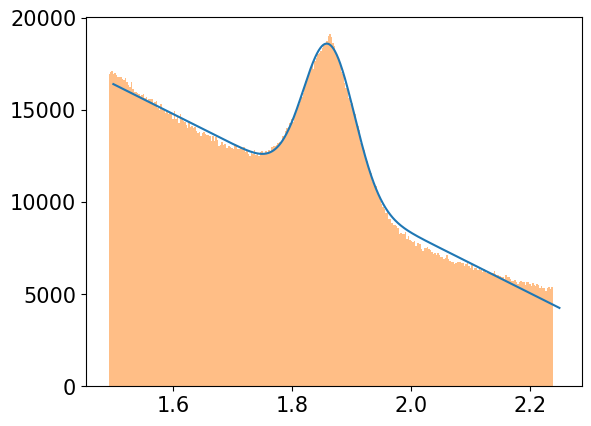

In [10]:
x = np.arange(1.5,2.25, 0.001)
plt.plot(x, A1*norm.pdf(x,loc=Mu1, scale=Sigma1)+Pedestal1+ Slope1*x)
plt.hist(df["mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS), align="mid", alpha=0.5)
plt.show()

In [11]:
integ, error = quad(norm.pdf, Mu1-3*Sigma1, Mu1+3*Sigma1,args=(Mu1,Sigma1) )
print("This is the value between -3 sigma and +3 sigma:", integ)
print("This is the counts: integral*amplitued/bin_width:",integ*A1/STEP)

This is the value between -3 sigma and +3 sigma: 0.9973002039367399
This is the counts: integral*amplitued/bin_width: 346573.51909019356


In [12]:
# by summing bins:
counts, edges, _ = ax.hist(df["mass"], bins=N_BINS, range=(MIN_MASS, MAX_MASS), align="mid", alpha=0.5)
centers = ( edges[:-1] + edges[1:] ) / 2.
mass_mask = pd.Series(centers).between(Mu1-3*Sigma1, Mu1+3*Sigma1)
Under_tot = np.sum(counts[mass_mask])
Under_linear = np.sum( Pedestal1 + centers[mass_mask]*Slope1 )
Under_Gauss = Under_tot - Under_linear
print("Conteggio D0 da somma dei conteggi dei bin:", Under_Gauss)

Conteggio D0 da somma dei conteggi dei bin: 345033.9552021641
